# Q4 — Demographics: age and sex split by drug × top reaction

**Question.** Who is reporting which side effects? For each drug's top-5 reactions, compute median age, % female, % male, and n.

**Plan.**
1. Find each drug's top-5 reactions (by report count).
2. Per (drug, reaction): median age (in years), % female, % male, n.
3. Save the pivot table to CSV.
4. Heatmap of median age across drug × reaction.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from src.load_data import load_adverse_events
from src.cleaning import APPROVED_GLP1_DRUGS, normalize_age_to_years, top_reactions_per_drug
from src.plotting import apply_style, save_fig, save_table

apply_style()

In [2]:
ae = load_adverse_events()
ae = normalize_age_to_years(ae)
glp1 = ae[ae["generic_name"].isin(APPROVED_GLP1_DRUGS)].copy()
print("GLP-1 reaction-level rows:", len(glp1))
print("patient_sex values:", glp1["patient_sex"].value_counts(dropna=False).to_dict())

GLP-1 reaction-level rows: 149209
patient_sex values: {'Female': 97614, 'Male': 45245, 'Unknown': 6350}


## 1. Top 5 reactions per drug

In [3]:
top5 = top_reactions_per_drug(glp1, top_n=5)
top5

,generic_name,reaction,n_reports,rank
0,albiglutide,Device use error,2699,1.0
1,albiglutide,Accidental exposure to product,840,2.0
2,albiglutide,Drug dose omission,662,3.0
3,albiglutide,Device leakage,620,4.0
4,albiglutide,Product quality issue,483,5.0
5,dulaglutide,Nausea,1140,1.0
6,dulaglutide,Blood glucose increased,440,2.0
7,dulaglutide,Vomiting,435,3.0
8,dulaglutide,Diarrhoea,393,4.0
9,dulaglutide,Injection site pain,379,5.0


## 2. Demographics per (drug, reaction)

`patient_sex` is coded `1=Male`, `2=Female` in FAERS, with some text mixed in newer pulls. Map defensively to be safe.

In [4]:
sex_map = {"1": "Male", "2": "Female", "Male": "Male", "Female": "Female", "M": "Male", "F": "Female"}
glp1["sex_clean"] = glp1["patient_sex"].astype(str).str.strip().map(sex_map)

merged = glp1.merge(top5[["generic_name", "reaction"]], on=["generic_name", "reaction"], how="inner")

def demographics(g: pd.DataFrame) -> pd.Series:
    """Median age + sex split + n for one (drug, reaction) group."""
    n = len(g)
    n_known_sex = g["sex_clean"].notna().sum()
    return pd.Series({
        "n_reports": n,
        "median_age_years": g["age_years"].median(),
        "pct_female": (g["sex_clean"] == "Female").sum() / max(n_known_sex, 1) * 100,
        "pct_male": (g["sex_clean"] == "Male").sum() / max(n_known_sex, 1) * 100,
        "pct_sex_unknown": (n - n_known_sex) / n * 100,
    })

demo = (
    merged.groupby(["generic_name", "reaction"], as_index=False)
          .apply(demographics, include_groups=False)
          .reset_index(drop=True)
)
demo = demo.round(1).sort_values(["generic_name", "n_reports"], ascending=[True, False]).reset_index(drop=True)
save_table(demo, "q4_demographics_by_drug_reaction")
demo

C:\Users\Dorsa\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\Dorsa\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\Dorsa\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


,generic_name,reaction,n_reports,median_age_years,pct_female,pct_male,pct_sex_unknown
0,albiglutide,Device use error,2699.0,58.0,59.3,40.7,0.9
1,albiglutide,Accidental exposure to product,840.0,58.0,53.5,46.5,1.4
2,albiglutide,Drug dose omission,662.0,59.0,61.5,38.5,1.2
3,albiglutide,Device leakage,620.0,58.0,54.6,45.4,1.3
4,albiglutide,Product quality issue,483.0,60.0,55.5,44.5,0.8
5,dulaglutide,Nausea,1140.0,57.0,69.7,30.3,2.5
6,dulaglutide,Blood glucose increased,440.0,62.0,56.2,43.8,2.5
7,dulaglutide,Vomiting,435.0,56.0,67.4,32.6,4.1
8,dulaglutide,Diarrhoea,393.0,58.0,59.1,40.9,3.6
9,dulaglutide,Injection site pain,379.0,61.0,63.5,36.5,1.6


## 3. Heatmap of median age (drug × reaction)

Cells with no data show up as gray — reaction profiles differ enough that not every drug has a row for every reaction.

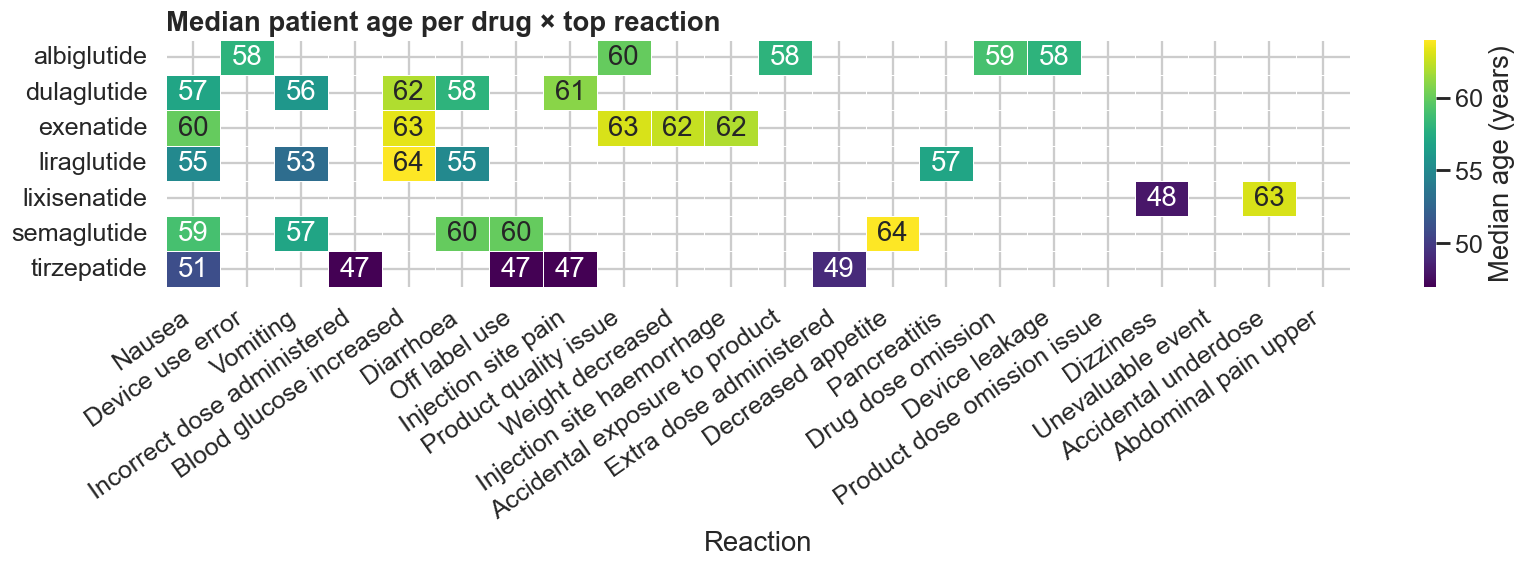

In [5]:
pivot = demo.pivot(index="generic_name", columns="reaction", values="median_age_years")
# Sort columns by total reports across all drugs so the busiest reactions are on the left.
col_order = demo.groupby("reaction")["n_reports"].sum().sort_values(ascending=False).index.tolist()
pivot = pivot.reindex(columns=[c for c in col_order if c in pivot.columns])

fig, ax = plt.subplots(figsize=(max(10, 0.7 * pivot.shape[1]), 5.5))
sns.heatmap(
    pivot, annot=True, fmt=".0f", cmap="viridis", cbar_kws={"label": "Median age (years)"},
    linewidths=0.4, linecolor="white", ax=ax,
)
ax.set_title("Median patient age per drug × top reaction")
ax.set_xlabel("Reaction")
ax.set_ylabel("")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
save_fig(fig, "q4_median_age_heatmap")
plt.show()

## 4. Bar chart: % female by drug (across all top reactions)

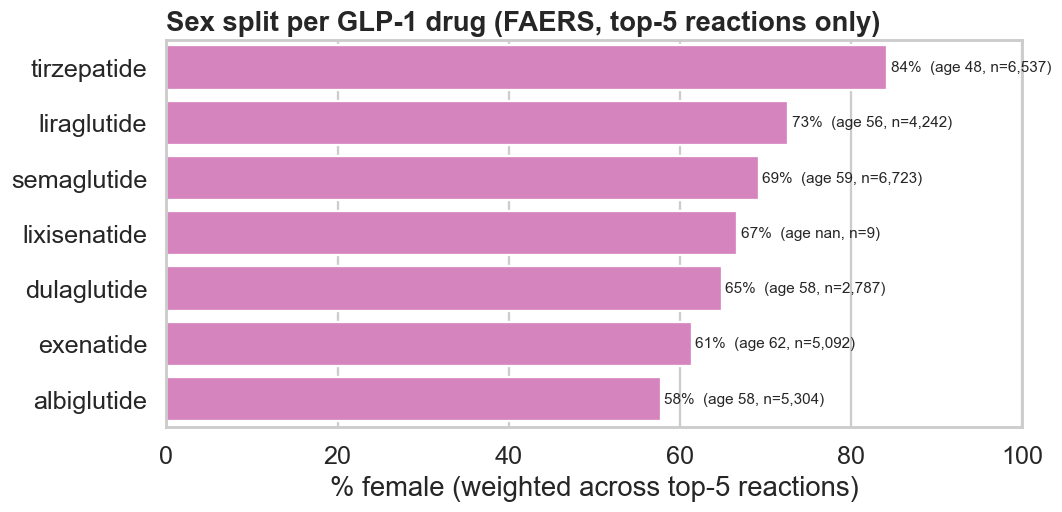

In [6]:
by_drug = (
    demo.groupby("generic_name", as_index=False)
        .apply(lambda d: pd.Series({
            "weighted_pct_female": np.average(d["pct_female"], weights=d["n_reports"]),
            "median_age_overall": np.average(d["median_age_years"], weights=d["n_reports"]),
            "total_n": d["n_reports"].sum(),
        }), include_groups=False)
        .reset_index(drop=True)
        .sort_values("weighted_pct_female", ascending=False)
)
save_table(by_drug.round(1), "q4_drug_level_demographics")

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=by_drug, x="weighted_pct_female", y="generic_name", color="#e377c2", ax=ax)
for i, row in by_drug.reset_index(drop=True).iterrows():
    ax.text(row["weighted_pct_female"] + 0.4, i,
            f"{row['weighted_pct_female']:.0f}%  (age {row['median_age_overall']:.0f}, n={int(row['total_n']):,})",
            va="center", fontsize=10)
ax.set_xlim(0, 100)
ax.set_xlabel("% female (weighted across top-5 reactions)")
ax.set_ylabel("")
ax.set_title("Sex split per GLP-1 drug (FAERS, top-5 reactions only)")
plt.tight_layout()
save_fig(fig, "q4_pct_female_by_drug")
plt.show()

In [7]:
log_path = PROJECT_ROOT / "outputs" / "findings_log.md"
highest_f = by_drug.iloc[0]
lowest_f = by_drug.iloc[-1]
oldest_drug = by_drug.sort_values("median_age_overall", ascending=False).iloc[0]
youngest_drug = by_drug.sort_values("median_age_overall", ascending=True).iloc[0]

entry = f"""
## 05 — Demographics (Q4)

### Findings
- Female skew is strongest for **{highest_f['generic_name']}** ({highest_f['weighted_pct_female']:.0f}% female, weighted age {highest_f['median_age_overall']:.0f}).
- Lowest female share: **{lowest_f['generic_name']}** ({lowest_f['weighted_pct_female']:.0f}%).
- Oldest median-age cohort: **{oldest_drug['generic_name']}** (~{oldest_drug['median_age_overall']:.0f} yrs).
- Youngest median-age cohort: **{youngest_drug['generic_name']}** (~{youngest_drug['median_age_overall']:.0f} yrs).
- Across all GLP-1 drugs the cohort skews female and middle-aged — consistent with the obesity/T2D indications and the post-2022 weight-loss usage shift.

### Issues / Limitations
- `patient_age_unit` had to be normalized to years; raw `patient_age` mixed years/months/weeks.
- `patient_sex` is coded numerically in raw FAERS — defensive mapping needed.
- 'Top 5 reactions' is per-drug, so the heatmap is sparse where two drugs don't share their top reactions.
- % female / % male denominators exclude reports with unknown sex (separately reported as `pct_sex_unknown`).
- Demographics still reflect *who reports*, not *who is treated* — caregivers and family members file disproportionately for women and older patients.

---
"""
with open(log_path, "a", encoding="utf-8") as f:
    f.write(entry)
print("Appended Q4.")

Appended Q4.


## Key Finding

GLP-1 FAERS reports skew **female and middle-aged across the entire class**, but the magnitude differs by drug: newer weight-loss-positioned drugs (semaglutide, tirzepatide) show the strongest female skew, while older T2D-only drugs (exenatide, dulaglutide) sit closer to the demographics of the diabetic population. None of this proves a sex-specific safety signal — reporting patterns mirror who *takes* (and who *reports about*) each drug.